In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
data = pd.read_csv(url, parse_dates=['Month'], index_col='Month')

print(data)

            Passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121
...                ...
1960-08-01         606
1960-09-01         508
1960-10-01         461
1960-11-01         390
1960-12-01         432

[144 rows x 1 columns]


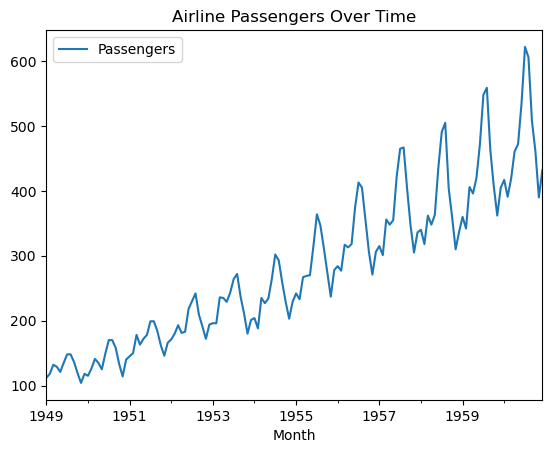

In [2]:
data.plot()
plt.title("Airline Passengers Over Time")
plt.show()

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Passengers  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB


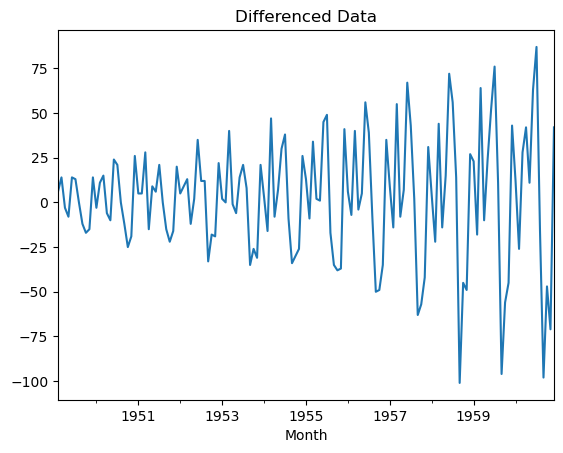

1961-01-01    466.665484
1961-02-01    472.011237
1961-03-01    467.888052
1961-04-01    467.032071
1961-05-01    469.645367
Freq: MS, dtype: float64


C:\Users\PYTHON\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\PYTHON\anaconda3\Lib\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


In [6]:
# Step 1: Differencing
data_diff = data['Passengers'].diff().dropna()
data_diff.plot()
plt.title("Differenced Data")
plt.show()
# Step 2: Train
from statsmodels.tsa.ar_model import AutoReg
model = AutoReg(data_diff, lags=2)
model_fit = model.fit()

# Step 3: Forecast (correct way)
pred = model_fit.forecast(steps=5)

# Step 4: Invert differencing
last_value = data['Passengers'].iloc[-1]
forecast_actual = last_value + pred.cumsum()

print(forecast_actual)

In [8]:
pred 

1961-01-01    34.665484
1961-02-01     5.345752
1961-03-01    -4.123185
1961-04-01    -0.855981
1961-05-01     2.613296
Freq: MS, dtype: float64

In [7]:
last_value

432